Diabetes Dataset

### Project Title:
 Predicting Diabetes Risk Using Supervised Machine Learning
### Objective: 
To develop and evaluate predictive models that classify individuals as diabetic or non-diabetic based on clinical health indicators.


### 📊 Dataset Overview
The dataset contains medical diagnostic measurements from female patients, including:
- Number of pregnancies
- Plasma glucose concentration
- Blood pressure
- Skin fold thickness
- Serum insulin levels
- Body Mass Index (BMI)
- Diabetes pedigree function
- Age
- Diabetes diagnosis (binary: 0 = non-diabetic, 1 = diabetic)


In [ ]:
#importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix,roc_curve,auc
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Importing Dataset
df = pd.read_csv(r"C:\Users\DELL LATITUDE\Downloads\Telegram Desktop\diabetes_dataset.csv")
df

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,tested_positive
1,1,85,66,29,0,26.6,0.351,31,tested_negative
2,8,183,64,0,0,23.3,0.672,32,tested_positive
3,1,89,66,23,94,28.1,0.167,21,tested_negative
4,0,137,40,35,168,43.1,2.288,33,tested_positive
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,tested_negative
764,2,122,70,27,0,36.8,0.340,27,tested_negative
765,5,121,72,23,112,26.2,0.245,30,tested_negative
766,1,126,60,0,0,30.1,0.349,47,tested_positive


A LITTLE EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    object 
dtypes: float64(2), int64(6), object(1)
memory usage: 54.1+ KB


In [5]:
df.isnull().sum()

preg     0
plas     0
pres     0
skin     0
insu     0
mass     0
pedi     0
age      0
class    0
dtype: int64

In [6]:
X = df.drop(axis = 1, columns= "class")
y = df["class"]

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
preg,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
plas,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
pres,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
skin,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
insu,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
mass,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
pedi,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


In [8]:
X

,preg,plas,pres,skin,insu,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [9]:
y.value_counts()

class
tested_negative    500
tested_positive    268
Name: count, dtype: int64

In [ ]:
#Standardizing data through Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns= X.columns)
X_scaled

,preg,plas,pres,skin,insu,mass,pedi,age
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496
...,...,...,...,...,...,...,...,...
763,1.827813,-0.622642,0.356432,1.722735,0.870031,0.115169,-0.908682,2.532136
764,-0.547919,0.034598,0.046245,0.405445,-0.692891,0.610154,-0.398282,-0.531023
765,0.342981,0.003301,0.149641,0.154533,0.279594,-0.735190,-0.685193,-0.275760
766,-0.844885,0.159787,-0.470732,-1.288212,-0.692891,-0.240205,-0.371101,1.170732


In [11]:
label_enc = LabelEncoder()
y_transformed = label_enc.fit_transform(y)

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y_transformed, test_size= 0.2, random_state= 42)

In [13]:
X_train

,preg,plas,pres,skin,insu,mass,pedi,age
60,-0.547919,-1.154694,-3.572597,-1.288212,-0.692891,-4.060474,-0.507006,-1.041549
618,1.530847,-0.278373,0.666618,0.217261,-0.692891,-0.481351,2.446670,1.425995
346,-0.844885,0.566649,-1.194501,-0.096379,0.027790,-0.417892,0.550035,-0.956462
294,-1.141852,1.255187,-0.987710,-1.288212,-0.692891,-1.280942,-0.658012,2.702312
231,0.639947,0.410164,0.563223,1.032726,2.519781,1.803195,-0.706334,1.085644
...,...,...,...,...,...,...,...,...
71,0.342981,0.566649,-0.263941,0.907270,0.522715,-0.430583,-0.183854,-0.616111
106,-0.844885,-0.779128,2.734528,-1.288212,-0.692891,-1.217483,-0.799958,-0.531023
270,1.827813,-0.622642,0.873409,1.032726,-0.692891,1.727044,2.005732,0.404942
435,-1.141852,0.629244,-3.572597,-1.288212,-0.692891,1.320902,-0.805998,-0.360847


In [14]:
log_reg = LogisticRegression()
model = log_reg.fit(X_train,y_train)
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
y_pred = log_reg.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [16]:
accuracy_score(y_test, y_pred)

0.7532467532467533

In [17]:
precision_score(y_test, y_pred)

0.6491228070175439

In [18]:
confusion_matrix (y_test, y_pred)

array([[79, 20],
       [18, 37]], dtype=int64)

In [19]:
f1_score(y_test, y_pred)

0.6607142857142857

In [20]:
y.value_counts()

class
tested_negative    500
tested_positive    268
Name: count, dtype: int64

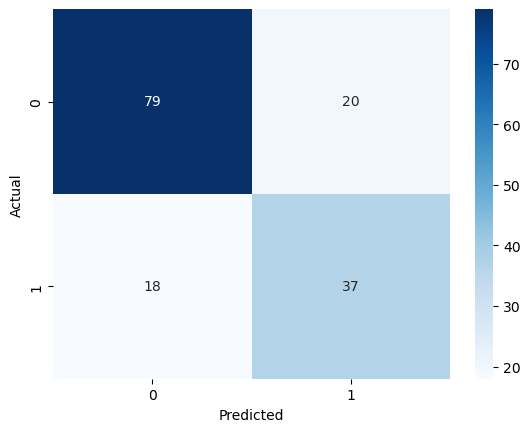

In [21]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot= True, fmt="d", cmap= "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
y_pred_proba = log_reg.predict_proba(X_test)[:,1]

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

In [24]:
roc_auc_score_lr = auc(fpr,tpr)
roc_auc_score_lr

0.8146923783287419

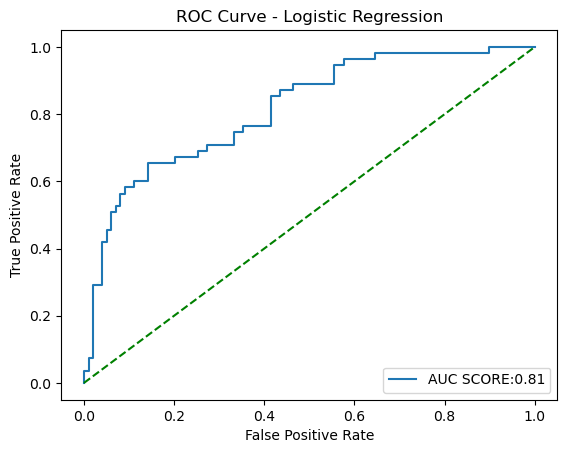

In [25]:
plt.plot(fpr,tpr , label =f"AUC SCORE:{roc_auc_score_lr:.2f}")
plt.legend()
plt.plot([0,1],[0,1], color="green", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()
plt.show()

In [26]:
ran_for = RandomForestClassifier(random_state= 42, n_estimators= 100 )
ran_for.fit(X_train,y_train)



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred_rf = ran_for.predict(X_test)

In [28]:
rf_balanced = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    class_weight="balanced"
)

rf_balanced.fit(X_train, y_train)
y_pred_rf_bal = rf_balanced.predict(X_test)

In [29]:
from imblearn.over_sampling import SMOTE

# Resample only the training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", pd.Series(y_train).value_counts())
print("After SMOTE:\n", pd.Series(y_train_sm).value_counts())

ImportError: cannot import name '_safe_tags' from 'sklearn.utils._tags' (C:\Users\DELL LATITUDE\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\_tags.py)

In [30]:
rf_smote = RandomForestClassifier(random_state=42, n_estimators=100)
rf_smote.fit(X_train_sm, y_train_sm)

# Predictions on the *original* test set
y_pred_rf_sm = rf_smote.predict(X_test)

NameError: name 'X_train_sm' is not defined

In [ ]:
accuracy_score(y_test,y_pred_rf)


0.7272727272727273

In [ ]:
accuracy_score(y_test,y_pred_rf_sm)


0.7597402597402597

In [ ]:
precision_score(y_test,y_pred_rf)

0.6181818181818182

In [ ]:
precision_score(y_test,y_pred_rf_sm)

0.6363636363636364

In [ ]:
f1_score(y_test,y_pred_rf)

0.6181818181818182

In [ ]:
f1_score(y_test,y_pred_rf_sm)

0.6942148760330579

In [ ]:
confusion_matrix(y_test,y_pred_rf_sm)

array([[75, 24],
       [13, 42]], dtype=int64)

In [ ]:
y_pred_proba_rf = ran_for.predict_proba(X_test)[:,1]

In [ ]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)

In [ ]:
roc_auc_score_rf = auc(fpr_rf,tpr_rf)
roc_auc_score_rf

0.813406795224977

In [ ]:
y_pred_proba_rf_sm = rf_smote.predict_proba(X_test)[:, 1]



In [ ]:

fpr_rf_sm, tpr_rf_sm, thresholds_rf_sm = roc_curve(y_test, y_pred_proba_rf_sm)



In [ ]:
auc_rf_sm = auc(fpr_rf_sm, tpr_rf_sm)
auc_rf_sm

0.8125803489439853

In [ ]:
roc_auc_score_rf_sm = auc(fpr_rf_sm, tpr_rf_sm)

C:\Users\DELL LATITUDE\AppData\Local\Temp\ipykernel_5608\980114900.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0,1],[0,1], 'k--', color='gray')  # diagonal line


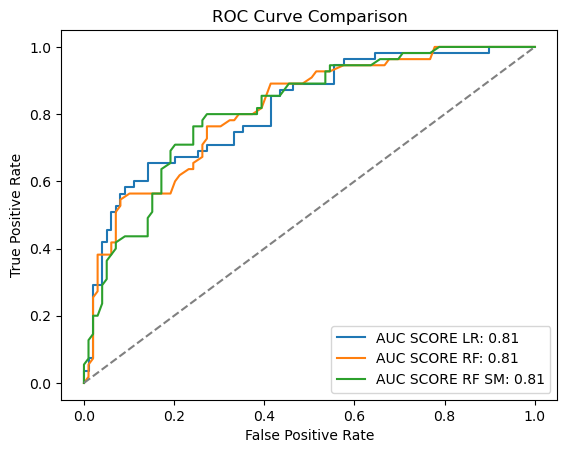

In [ ]:
plt.plot(fpr, tpr, label=f"AUC SCORE LR: {roc_auc_score_lr:.2f}")
plt.plot(fpr_rf, tpr_rf, label=f"AUC SCORE RF: {roc_auc_score_rf:.2f}")
plt.plot(fpr_rf_sm, tpr_rf_sm, label=f"AUC SCORE RF SM: {roc_auc_score_rf_sm:.2f}")

plt.plot([0,1],[0,1], 'k--', color='gray')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()


In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "RF + SMOTE"],
    "Accuracy": [accuracy_score(y_test, y_pred),
                 accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_rf_sm)],
    "Precision": [precision_score(y_test, y_pred),
                  precision_score(y_test, y_pred_rf),
                  precision_score(y_test, y_pred_rf_sm)],
    "F1 Score": [f1_score(y_test, y_pred),
                 f1_score(y_test, y_pred_rf),
                 f1_score(y_test, y_pred_rf_sm)],
    "ROC AUC": [roc_auc_score_lr,
                roc_auc_score_rf,
                roc_auc_score_rf_sm]
})
print(results)

NameError: name 'pd' is not defined

### 🔧 Methodology
- Data Preprocessing
- Checked for missing values and data integrity
- Scaled features using StandardScaler
- Encoded target variable using LabelEncoder
- Split data into training and test sets (80/20)
- 
### Model Development
- Trained three models:
- Logistic Regression (baseline)
- Random Forest Classifier
- Random Forest with SMOTE (Synthetic Minority Oversampling Technique)

### Class Imbalance Handling
- Applied class_weight='balanced' in Random Forest
- Used SMOTE to oversample the minority class in training data
- Performance Evaluation
- 
### Metrics: Accuracy, Precision, F1 Score, ROC-AUC
- Visualized confusion matrices and ROC curves for model comparison



### CONCLUSION

This project successfully demonstrated how machine learning can be applied to healthcare data to predict diabetes risk. By addressing class imbalance and comparing multiple models, the final pipeline achieved strong predictive performance and fairness. These insights can support early diagnosis and targeted interventions in clinical settings.